# Customer Churn Prediction

**Project Goal:**  
Predict which customers are likely to churn (leave the telecom company) so the business can take action to retain them.

**What I Did:**
- Loaded and explored the Telco Customer Churn dataset (7043 customers)
- Preprocessed data using scikit-learn Pipeline + ColumnTransformer
- Handled categorical and numeric features properly
- Trained a RandomForestClassifier
- Achieved overall accuracy of 0.79
- Noted that recall for churn class is 0.46 (model is better at predicting customers who stay)

**Key Learning:** 
Imbalanced datasets like churn require careful evaluation (accuracy alone is misleading). Future improvement can include SMOTE or better feature engineering.

**Tools:** pandas, scikit-learn (Pipeline, ColumnTransformer), Seaborn, Matplotlib

**GitHub:** https://github.com/Namit865/data-analysis-portfolio/tree/main/customer-churn-prediction#learning-outcomes

In [56]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape of Dataset:",df.shape)

Shape of Dataset: (7043, 21)


Target variable churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


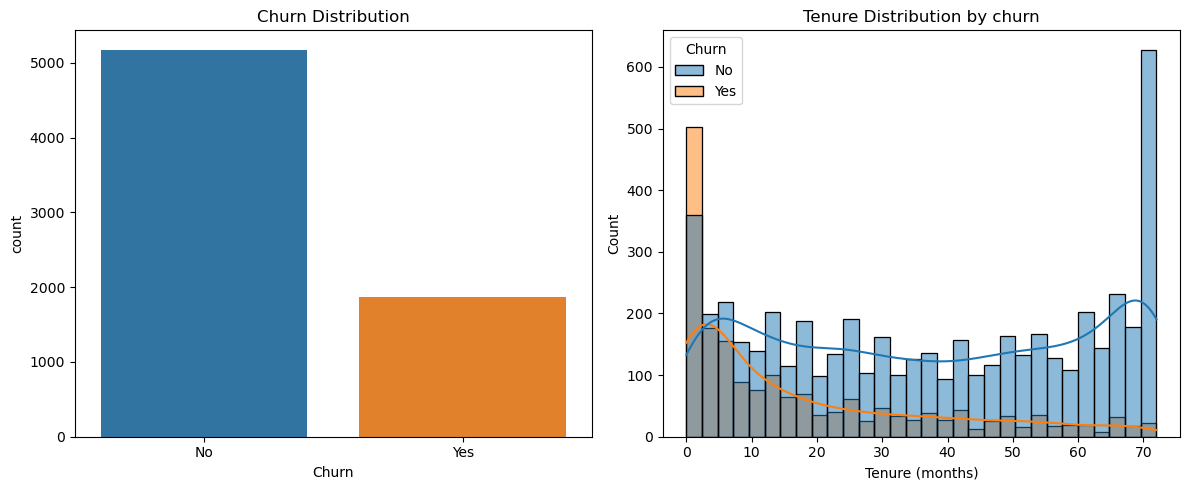

In [79]:
print("Target variable churn distribution:")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

# Visualizations
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
sns.countplot(x = 'Churn',hue = 'Churn',data = df)
plt.title('Churn Distribution')

plt.subplot(1, 2, 2)
sns.histplot(data = df,x = 'tenure',hue = 'Churn',bins = 30,kde = True)
plt.title('Tenure Distribution by churn')
plt.xlabel('Tenure (months)')

plt.tight_layout()
plt.show()

In [100]:
# Convert object variable to numeric 
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

# Prepare target
x = df.drop(columns = ['Churn','customerID'])
y = df['Churn'].map({'Yes' : 1, 'No' : 0})

# Train-test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

#Defining all numerics and categorical columns
numeric_cols = ['tenure','MonthlyCharges','TotalCharges']
categorical_cols = ['gender','Partner','SeniorCitizen','Dependents','PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

# Preprocessor
preprocessor = ColumnTransformer([
    ('num',SimpleImputer(strategy='median'),numeric_cols),
    ('cat',Pipeline([
        ('imputer',SimpleImputer(strategy = 'most_frequent')),
        ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
    ]),categorical_cols)
],remainder = 'drop')

print("Preprocessor created Successfully!")

# Full Pipeline
model_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',RandomForestClassifier(n_estimators=100,random_state = 42,class_weight='balanced')),
])

# Training Model
model_pipeline.fit(x_train,y_train)

# Prediction
pred = model_pipeline.predict(x_test)

# Evaluate
print('\nAccuracy:',round(accuracy_score(y_test,pred),4))
print('\nClassification Report:')
print(classification_report(y_test,pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test,pred))

Preprocessor created Successfully!

Accuracy: 0.7963

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1036
           1       0.67      0.45      0.54       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.70      1409
weighted avg       0.78      0.80      0.78      1409

Confusion Matrix:
[[954  82]
 [205 168]]


### Confusion Matrix Explanation

- **954 (True Negative)**: Model correctly predicted these customers would **stay**, and they actually stayed.
- **82 (False Positive)**: Model wrongly predicted these customers would churn, but they actually stayed.
- **205 (False Negative)**: Model wrongly predicted these customers would stay, but they actually **churned**.
- **168 (True Positive)**: Model correctly predicted these customers would churn, and they actually left.

**Business Insight**:  
The model is quite good at identifying loyal customers, but it misses 205 customers who eventually churned. In real business, catching these "False Negatives" is often more important because losing a customer is costly. We may need to improve recall for the churn class in future iterations.